In [62]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [63]:
import json
from PIL import Image
from torch.utils.data import Dataset

class ImageNet100Dataset(Dataset):
    def __init__(self, root_dir, indices=None):
        self.root_dir = root_dir
        with open(f"{root_dir}/labels.json") as f:
            self.labels = json.load(f)
        
        self.indices = indices if indices is not None else list(range(len(self.labels)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img = Image.open(f"{self.root_dir}/imagenet100_128px/{real_idx}.jpg").convert("RGB")
        label = self.labels[real_idx]
        return img, label

In [64]:
import os

folder_path = '../data'
files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
print(files)

with open("../data/labels.json") as f: 
    labels = json.load(f) 

['class_names.json', 'labels.json', 'permutation_set.json']


In [65]:
import json
import random

from matplotlib.pylab import tri

with open("../data/labels.json") as f: 
    labels = json.load(f) 
with open("../data/class_names.json") as f: # optional, just for reference
    class_names = json.load(f)  

SEED = 42
all_classes = list(range(100))
random.Random(SEED).shuffle(all_classes)

holdout_classes = set(all_classes[:20])
train_classes = set(all_classes[20:])

train_indices = [i for i, lbl in enumerate(labels) if lbl in train_classes]
holdout_indices = [i for i, lbl in enumerate(labels) if lbl in holdout_classes]

print(f"Train images: {len(train_indices)}")    
print(f"Holdout images: {len(holdout_indices)}")

train_base = ImageNet100Dataset("../data", indices=train_indices)
test_base = ImageNet100Dataset("../data", indices=holdout_indices)

img = Image.open(f"../data/imagenet100_128px/{train_indices[5]}.jpg").convert("RGB")
img, label = train_base[5]
label

Train images: 101712
Holdout images: 24977


0

In [66]:
def get_grid_positions(img_size=128, grid_size=3):
    """Fixed 3x3 grid cell coordinates - same every time, regardless of permutation."""
    patch_size = img_size // grid_size  # 128 // 3 ≈ 42
    positions = []
    for row in range(grid_size):
        for col in range(grid_size):
            x = col * patch_size
            y = row * patch_size
            positions.append((x, y))
    return positions  # always 9 fixed (x,y) pairs, e.g. [(0,0),(42,0),(84,0),(0,42),...]

In [67]:
import random
from torchvision.transforms import v2
import torch

class DiscreteRotation:
    def __init__(self, angles=(0, 90, 180, 270)):
        self.angles = angles

    def __call__(self, img):
        angle = random.choice(self.angles)
        if angle == 0:
            return img
        return img.rotate(angle, expand=False) 

patch_transform = v2.Compose([
    v2.ToImage(),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # DiscreteRotation(),
    v2.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    v2.RandomGrayscale(p=0.1),
    v2.ToDtype(torch.float32, scale=True),
])

In [68]:
class JigsawDataset(Dataset):
    def __init__(self, image_dataset, permutation_set, transform=None, seed=None):
        self.image_dataset = image_dataset
        self.permutation_set = permutation_set
        self.transform = transform
        self.rng = random.Random(seed)
        self.grid_positions = get_grid_positions()

    def __len__(self):
        return len(self.image_dataset)

    def __getitem__(self, idx):
        img, label = self.image_dataset[idx]

        patch_size = 128 // 3
        patches = [
            img.crop((x, y, x + patch_size, y + patch_size))
            for (x, y) in self.grid_positions
        ]

        perm_index = self.rng.randint(0, len(self.permutation_set) - 1)
        perm = self.permutation_set[perm_index]  # e.g. (2, 0, 4, 1, 8, 5, 3, 7, 6)
        shuffled_patches = [patches[i] for i in perm]

        if self.transform:
            shuffled_patches = [self.transform(patch) for patch in shuffled_patches]

        return shuffled_patches, perm_index

In [69]:
# Temp code:
from puzzly.data.permutations import generate_permutation_set, save_permutation_set, load_permutation_set

permutation_set = generate_permutation_set(num_patches=9, num_permutations=50, seed=42)
save_permutation_set(permutation_set, "../data/permutation_set.json")

permutation_set = load_permutation_set("../data/permutation_set.json")

### Making Datasets

In [70]:
train_data = JigsawDataset(train_base, permutation_set=permutation_set, transform=patch_transform, seed=SEED)
test_data = JigsawDataset(test_base, permutation_set=permutation_set, transform=patch_transform, seed=SEED)

In [71]:
def visualize_jigsaw(patches, grid_size=3):
    """Visualize the shuffled patches in a grid."""
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    fig.suptitle(f"{class_names[labels[train_indices[random_idx]]]} - Shuffled")
    for i, patch in enumerate(patches):
        row = i // grid_size
        col = i % grid_size
        axes[row, col].imshow(patch.permute(1, 2, 0).numpy())
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

def unscramble_jigsaw(permutation_list, shuffled_patches, grid_size=3):
    """Reconstructs the original patch order from shuffled patches + the perm that was applied."""
    import matplotlib.pyplot as plt
    
    original_order = [0] * len(shuffled_patches)
    for i, patch_index in enumerate(permutation_list):
        original_order[patch_index] = shuffled_patches[i]

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    fig.suptitle(f"{class_names[labels[train_indices[random_idx]]]} - Unscrambled")
    for i, patch in enumerate(original_order):
        row, col = i // grid_size, i % grid_size
        axes[row, col].imshow(patch.permute(1, 2, 0).numpy())  # Convert from (C,H,W) to (H,W,C) for display
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

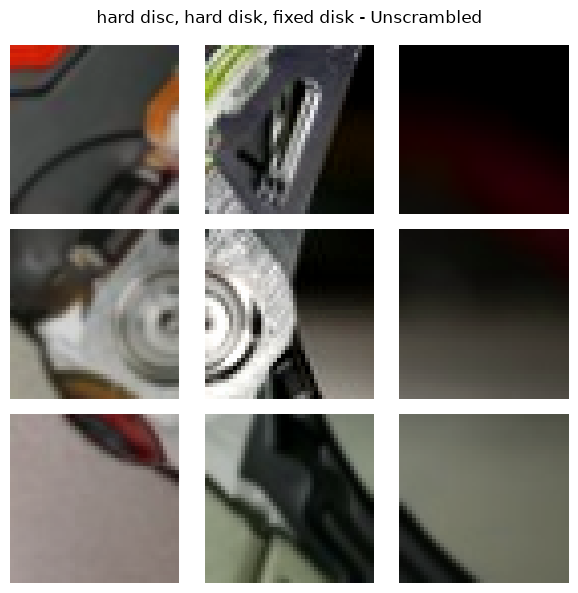

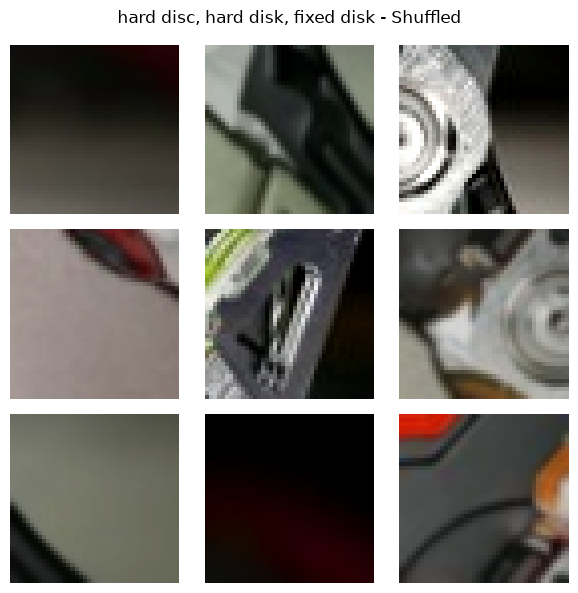

In [ ]:
# random.seed(SEED)

# random_idx = random.randint(0, len(train_data) - 1)
# shuffled_patches, perm_index = train_data[random_idx]
# unscramble_jigsaw(permutation_set[perm_index], shuffled_patches, 3)
# visualize_jigsaw(shuffled_patches, 3)


### Dataloaders

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=os.cpu_count())
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=os.cpu_count())

In [ ]:
# train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x15c14416d50>,
 <torch.utils.data.dataloader.DataLoader at 0x15c18108d60>)

In [75]:
# list(train_loader)[0][0]

In [76]:
# train_batch = next(iter(train_loader))
# train_batch

In [ ]:
# from torchvision.models import resnet18

# model = resnet18(weights=None)
# model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [78]:
from torchvision.models import resnet18

import torch.nn as nn

class JigsawResNet18(nn.Module):
    def __init__(self, num_permutations=50):
        super().__init__()
        base = resnet18(weights=None)
        self.encoder = nn.Sequential(*list(base.children())[:-1])  
        self.classifier = nn.Sequential(
            nn.Linear(512 * 9, 512),
            nn.ReLU(),
            nn.Linear(512, num_permutations)
        )

    def forward(self, patches):  # (batch, 9, C, H, W)
        batch_size = patches.size(0)
        patches = patches.view(-1, *patches.shape[2:])
        features = self.encoder(patches).flatten(1)
        features = features.view(batch_size, -1)
        return self.classifier(features)

model_0 = JigsawResNet18(num_permutations=50).to(device)

In [ ]:
# from torchinfo import summary

# model_1 = resnet18(weights=None)
# summary(model_1, input_size=(32, 3, 42, 42), col_names=["input_size", "output_size", "num_params", "trainable"])

In [ ]:
# summary(model_0, input_size=(32, 9, 3, 42, 42), col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
JigsawResNet18                                [32, 9, 3, 42, 42]        [32, 50]                  --                        True
├─Sequential: 1-1                             [288, 3, 42, 42]          [288, 512, 1, 1]          --                        True
│    └─Conv2d: 2-1                            [288, 3, 42, 42]          [288, 64, 21, 21]         9,408                     True
│    └─BatchNorm2d: 2-2                       [288, 64, 21, 21]         [288, 64, 21, 21]         128                       True
│    └─ReLU: 2-3                              [288, 64, 21, 21]         [288, 64, 21, 21]         --                        --
│    └─MaxPool2d: 2-4                         [288, 64, 21, 21]         [288, 64, 11, 11]         --                        --
│    └─Sequential: 2-5                        [288, 64, 11, 11]         [288, 64, 11, 11]       

In [ ]:
# torch.stack(train_data[0][0]).unsqueeze(0).shape  # shape of a single patch in the first sample of the training dataset

torch.Size([1, 9, 3, 42, 42])

In [ ]:
# model_0(torch.stack(train_data[0][0].to(device)).unsqueeze(0)) # this will print the shape of the features tensor after encoding the patches, which should be (batch_size, 512 * 9) before passing it to the classifier.

tensor([[ 0.3320, -0.0984, -0.0825, -0.2231, -0.0402, -0.3084,  0.1943, -0.2555,
          0.1630,  0.0841, -0.0570, -0.0544,  0.0975,  0.2436,  0.0729, -0.1872,
         -0.3553,  0.0838, -0.4545,  0.0303, -0.1642,  0.6116,  0.1265, -0.0148,
          0.0771,  0.1852,  0.0488,  0.1612, -0.0375, -0.2135,  0.0312,  0.3791,
          0.1833,  0.0759, -0.3786, -0.1342, -0.0873, -0.2998,  0.4627, -0.1572,
         -0.4004, -0.0981, -0.2595,  0.1964,  0.0097, -0.0695, -0.1071, -0.6480,
          0.2540, -0.0047]], grad_fn=<AddmmBackward0>)

### Loss and Optimizer

In [83]:
from torch import nn, optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_0.parameters(), lr=1e-3, weight_decay=1e-4)

In [85]:
from torchmetrics.classification import MulticlassAccuracy

metrics = MulticlassAccuracy(num_classes=50).to(device)

In [89]:
from tqdm import tqdm

In [ ]:
def train_step(model, train_dataloader, loss_fn, optimizer, device, metrics):
    model.train()
    metrics.reset()

    for batch, (patches, perm_indices) in enumerate(train_dataloader):
        patches, perm_indices = patches.to(device), perm_indices.to(device)

        y_logits = model(patches) # returns the raw values (50 elements)
        y_probs = torch.softmax(y_logits, dim=1)
        y_preds = torch.argmax(y_probs, dim=1)

        metrics.update(y_preds, perm_indices)
        print(perm_indices)
        print(y_logits)

        # output = loss_fn(y_logits, perm_indices)


train_step(model_0, train_loader, loss_fn, optimizer, device, metrics)
        

c:\Users\vvrao\Porfolio\Puzzly\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
